In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_csv("student-performance.csv")

In [7]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72.518868,72.341163,74.604843
1,female,group C,some college,standard,completed,69.372786,90.693512,88.434536
2,female,group B,master's degree,standard,none,90.747297,95.972689,93.364383
3,male,group A,associate's degree,free/reduced,none,47.311826,57.336038,44.197319
4,male,group C,some college,standard,none,76.948720,78.920104,75.317157


In [8]:
new_df=df[['reading score' , 'writing score']]
new_df.head()

,reading score,writing score
0,72.341163,74.604843
1,90.693512,88.434536
2,95.972689,93.364383
3,57.336038,44.197319
4,78.920104,75.317157


In [9]:
new_df=df.drop(columns=['gender' ,'race/ethnicity' , 'parental level of education' , 'lunch' , 'test preparation course' , 'math score'  ])
new_df

,reading score,writing score
0,72.341163,74.604843
1,90.693512,88.434536
2,95.972689,93.364383
3,57.336038,44.197319
4,78.920104,75.317157
...,...,...
995,99.461313,95.695893
996,55.106847,55.988351
997,71.709248,65.408511
998,78.607313,77.960825


In [10]:
new_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   reading score  1000 non-null   float64
 1   writing score  1000 non-null   float64
dtypes: float64(2)
memory usage: 15.8 KB


In [11]:
new_df.shape

(1000, 2)

In [12]:
new_df.describe

<bound method NDFrame.describe of      reading score  writing score
0        72.341163      74.604843
1        90.693512      88.434536
2        95.972689      93.364383
3        57.336038      44.197319
4        78.920104      75.317157
..             ...            ...
995      99.461313      95.695893
996      55.106847      55.988351
997      71.709248      65.408511
998      78.607313      77.960825
999      86.914925      86.684998

[1000 rows x 2 columns]>

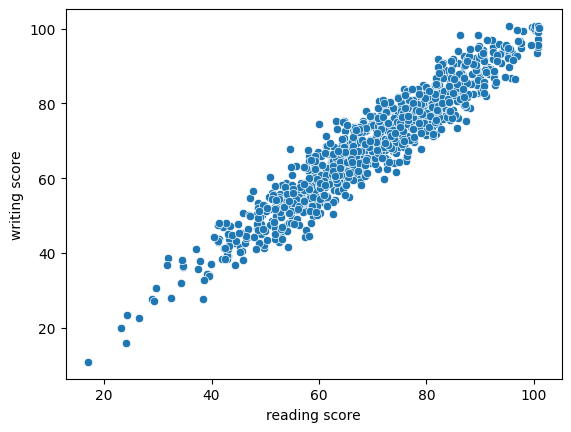

In [13]:
sns.scatterplot(data=df,x='reading score',y='writing score')
plt.show()


In [14]:
x=new_df['reading score']
y=new_df['writing score']

In [15]:
X = new_df['reading score']
y = new_df['writing score']
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                        test_size=0.3 , random_state=0)

In [16]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)



(700,)
(700,)
(300,)
(300,)


In [17]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()

In [18]:
x_Train=X_train.values.reshape(-1,1)
x_Test=X_test.values.reshape(-1,1)


In [19]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)



(700,)
(700,)
(300,)
(300,)


In [20]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(x_Train , y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [21]:
print(lr.intercept_)
print (lr.coef_)

-0.7953241893015246
[0.99386597]


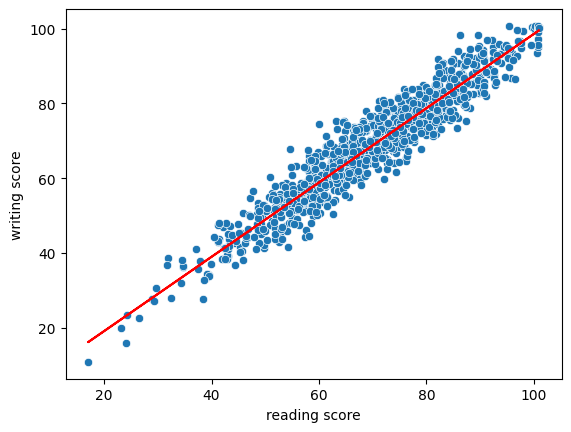

In [22]:
sns.scatterplot(data=df,x='reading score',y='writing score')
plt.plot(x_Train, lr.predict(x_Train), color='red')
plt.show()


In [27]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = new_df[['reading score']]
y = new_df['writing score']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0
)

lr = LinearRegression()

lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

import numpy as np

lr.predict(np.array([[0]]))

c:\Users\ASUS\Desktop\code\ML\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([-0.79532419])

In [28]:
type(y_pred)

numpy.ndarray

In [30]:
y_pred.shape

(300,)

Text(0, 0.5, 'Output')

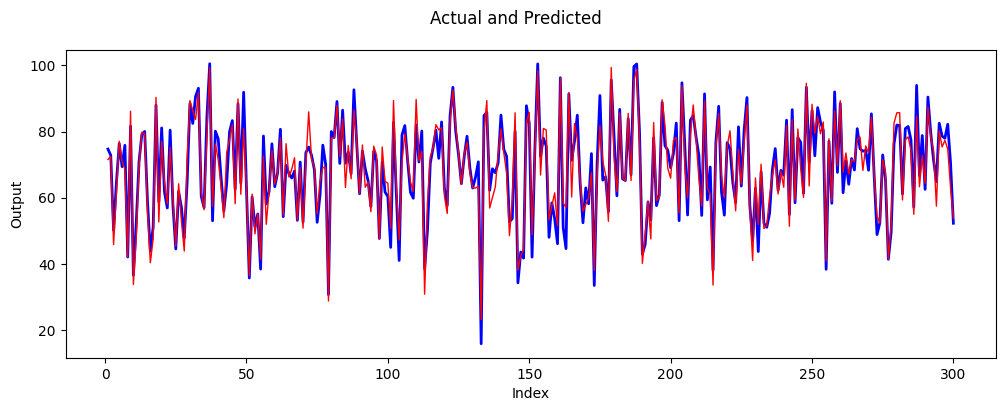

In [31]:
import matplotlib.pyplot as plt
c = [i for i in range(1,301)] 
fig = plt.figure(figsize=(12,4))
plt.plot(c,y_test, color="blue", linewidth=2, linestyle="-")
plt.plot(c,y_pred, color="red",  linewidth=1, linestyle="-")
fig.suptitle('Actual and Predicted')              
plt.xlabel('Index')                               
plt.ylabel('Output') 

In [32]:
from sklearn.metrics import root_mean_squared_error, r2_score
rmse = root_mean_squared_error(y_test, y_pred)
r_squared = r2_score(y_test, y_pred)
print('Mean_Squared_Error :' ,rmse)
print('r_square_value :',r_squared)

Mean_Squared_Error : 4.112072053676197
r_square_value : 0.9206222738934423
